In [1]:
import numpy as np
import matplotlib.pyplot as plt

L'obiettivo è visualizzare le distribuzioni delle frazioni di eventi per le diverse feautures per segnale e rumore sovrapposte.

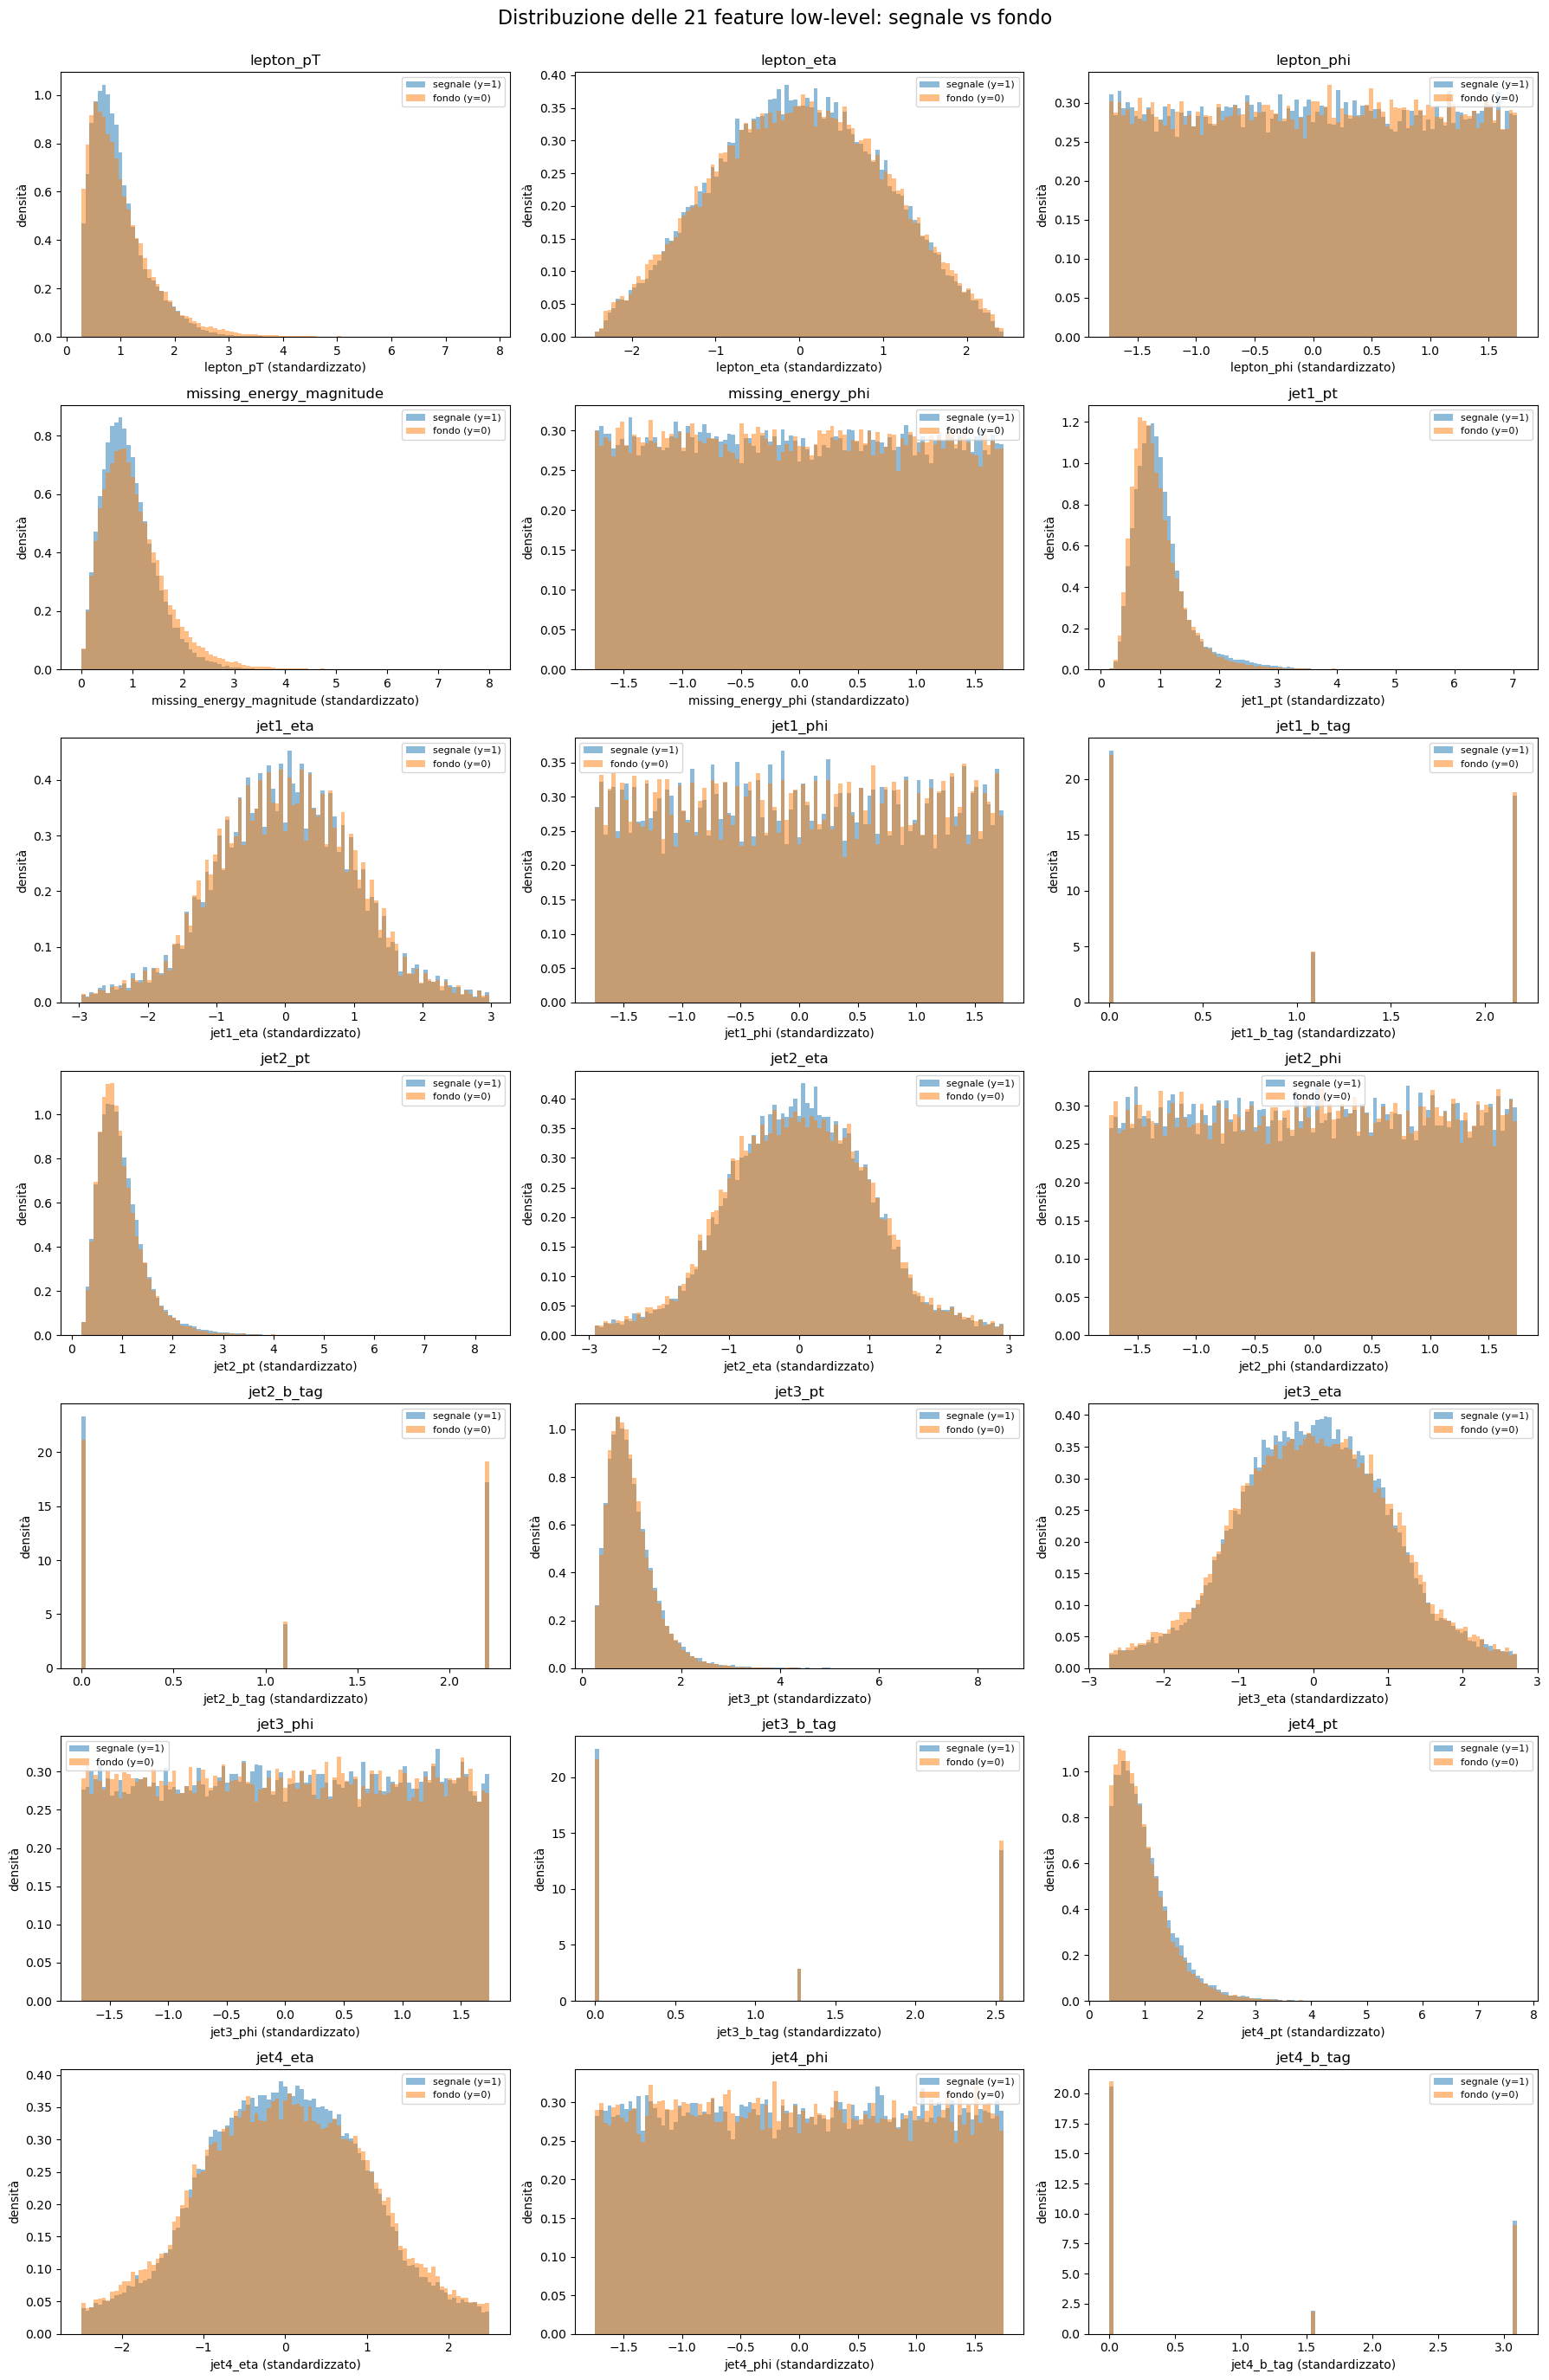

In [2]:
X = np.load("../data/processed_small/X.npy")
y = np.load("../data/processed_small/y.npy").ravel()

lepton_pT = X[:, 0]  # colonna 0 = lepton_pT (vedi src/features.py)

segnale = lepton_pT[y == 1]
fondo = lepton_pT[y == 0]

import sys
sys.path.append("..")
from src.features import LOW_LEVEL

segnale_all = X[y == 1]
fondo_all = X[y == 0]

fig, axes = plt.subplots(7, 3, figsize=(18, 28))


for i, (ax, nome) in enumerate(zip(axes.flat, LOW_LEVEL)):
    col = X[:, i]
    bins = np.linspace(col.min(), col.max(), 100)

    ax.hist(segnale_all[:, i], bins=bins, alpha=0.5, density=True, label="segnale (y=1)")
    ax.hist(fondo_all[:, i], bins=bins, alpha=0.5, density=True, label="fondo (y=0)")
    ax.set_title(nome)
    ax.set_xlabel(nome + " (standardizzato)")
    ax.set_ylabel("densità")
    ax.legend(fontsize=8)

fig.suptitle("Distribuzione delle 21 feature low-level: segnale vs fondo", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()




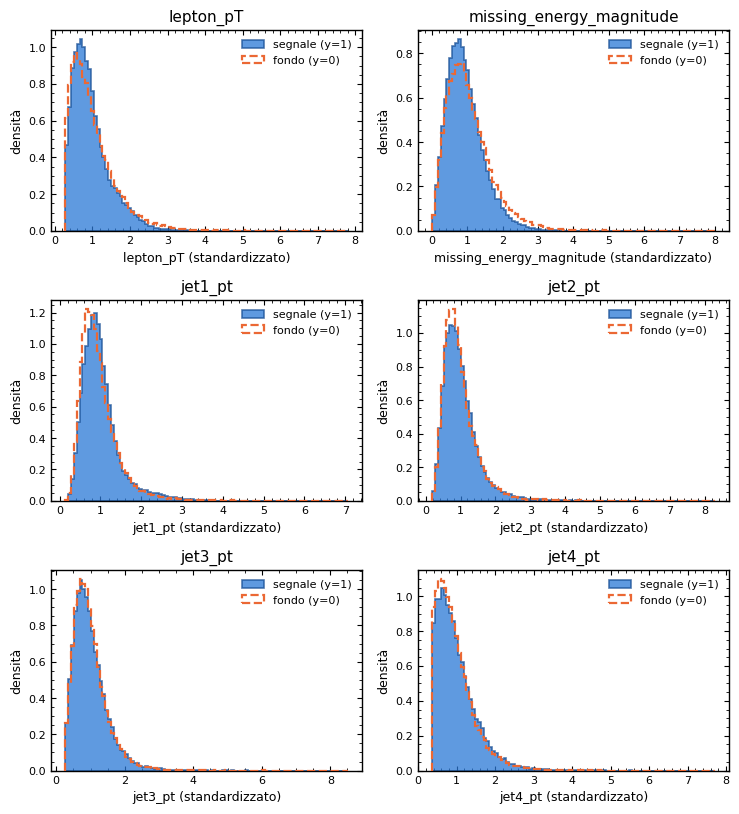

In [3]:
# immagine con solo i pT e le energie (niente phi/eta, totale 6)
# stile "HEP paper": segnale pieno blu, fondo contorno tratteggiato arancio
indici_pt_energia = [0, 3, 5, 9, 13, 17]  # lepton_pT, missing_energy_magnitude, jet1-4_pt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Source Sans Pro", "Source Sans 3", "Segoe UI", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top": True,
    "ytick.right": True,
})

SIGNAL_COLOR = "#2a78d6"   # blu
EDGE_COLOR = "#184f95"     # blu scuro, contorno del segnale
FONDO_COLOR = "#eb6834"    # arancio, tratteggio del fondo

fig, axes = plt.subplots(3, 2, figsize=(7.5, 8.5))
for ax, i in zip(axes.flat, indici_pt_energia):
    nome = LOW_LEVEL[i]
    col = X[:, i]
    bins = np.linspace(col.min(), col.max(), 100)

    ax.hist(
        segnale_all[:, i], bins=bins, density=True,
        histtype="stepfilled", facecolor=SIGNAL_COLOR, edgecolor=EDGE_COLOR,
        alpha=0.75, linewidth=1.2, label="segnale (y=1)", zorder=2,
    )
    ax.hist(
        fondo_all[:, i], bins=bins, density=True,
        histtype="step", color=FONDO_COLOR, linewidth=1.6, linestyle="--",
        label="fondo (y=0)", zorder=3,
    )

    ax.set_title(nome, fontsize=11)
    ax.set_xlabel(nome + " (standardizzato)", fontsize=9)
    ax.set_ylabel("densità", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, frameon=False, loc="upper right")
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

#fig.suptitle("Distribuzione di alcune low feature: segnale vs fondo", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


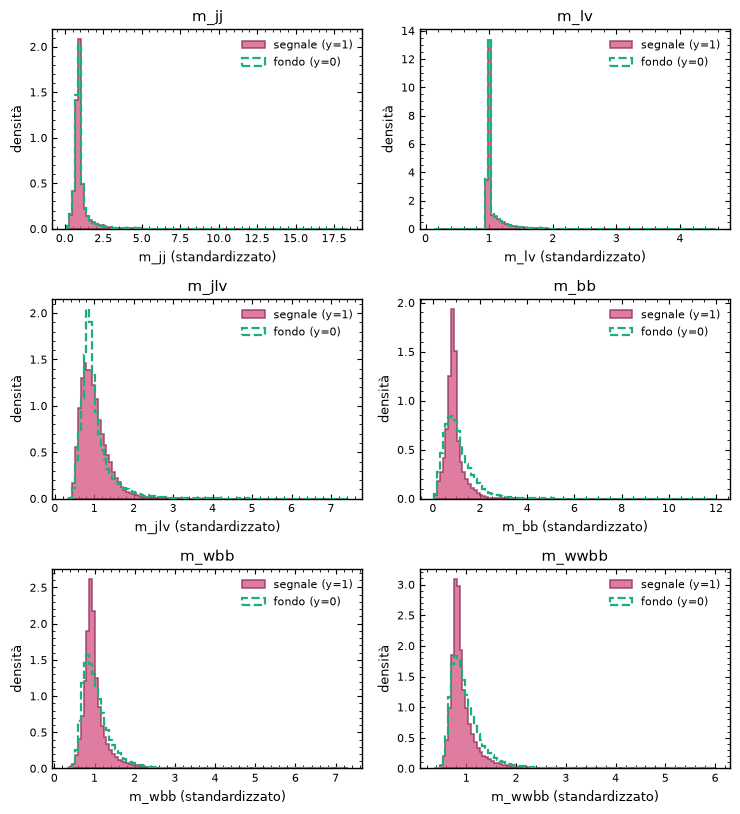

In [11]:
from src.features import HIGH_LEVEL

# 6 delle 7 feature high-level (si esclude m_jjj, meno centrale al confronto segnale/fondo)
indici_high = [21, 23, 24, 25, 26, 27]  # m_jj, m_lv, m_jlv, m_bb, m_wbb, m_wwbb

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Source Sans Pro", "Source Sans 3", "Segoe UI", "Helvetica Neue", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.top": True,
    "ytick.right": True,
})

SIGNAL_COLOR = "#d55181"   # fucsia smorzato (diverso dal plot pT/energia)
EDGE_COLOR = "#8a2f5c"     # bordo più scuro
FONDO_COLOR = "#1baf7a"    # verde acqua, tratteggio del fondo

fig, axes = plt.subplots(3, 2, figsize=(7.5, 8.5))
for ax, i in zip(axes.flat, indici_high):
    nome = HIGH_LEVEL[i - 21]
    col = X[:, i]
    bins = np.linspace(col.min(), col.max(), 100)

    ax.hist(
        segnale_all[:, i], bins=bins, density=True,
        histtype="stepfilled", facecolor=SIGNAL_COLOR, edgecolor=EDGE_COLOR,
        alpha=0.75, linewidth=1.2, label="segnale (y=1)", zorder=2,
    )
    ax.hist(
        fondo_all[:, i], bins=bins, density=True,
        histtype="step", color=FONDO_COLOR, linewidth=1.6, linestyle="--",
        label="fondo (y=0)", zorder=3,
    )

    ax.set_title(nome, fontsize=11)
    ax.set_xlabel(nome + " (standardizzato)", fontsize=9)
    ax.set_ylabel("densità", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, frameon=False, loc="upper right")
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

#fig.suptitle("Distribuzione delle feature high-level: segnale vs fondo", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [5]:
# qui